In [171]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["font.size"] = 14

from tqdm import tqdm

import h5py
import colour
import powerlaw
from scipy.signal import savgol_filter
import multiprocessing
import time
import os

import sys
sys.path.append('../')

from tracker import runAndTumble, runAndTumbleArbBoundary, loadAntData, computeMSD

# Update source files before running each cell
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup the generation function with parameters (bounded)

In [251]:
# Translational diffusion
Dx = 0.0

# Generate the outer shape of the arena (including the door)
boxSize = np.array([200, 140])
doorSize = [5, 35]
doorOffset = 25

# Given in clockwise order since it's an outer boundary
boundaryPoints = np.array([[0, 0],
                           [0, boxSize[1]],
                           [boxSize[0], boxSize[1]],
                           [boxSize[0], doorOffset + doorSize[1]],
                           [boxSize[0] + doorSize[0], doorOffset + doorSize[1]],
                           [boxSize[0] + doorSize[0], doorOffset],
                           [boxSize[0], doorOffset],
                           [boxSize[0], 0]])

postSize = [8, 6]
postCenters = np.array([[15, 15],
                        [100, 15],
                        [185, 15],
                        [15, 125],
                        [100, 125],
                        [185, 125]])

# Given in counter-clockwise order, since its an inner boundary
pointOffsets = np.array([[postSize[0], -postSize[1]],
                         [postSize[0], postSize[1]],
                         [-postSize[0], postSize[1]],
                         [-postSize[0], -postSize[1]]]) / 2

postBoundaries = [center + pointOffsets for center in postCenters]

allBoundaries = [boundaryPoints] + postBoundaries

# Starting position at the door
x0 = np.array([boxSize[0] + doorSize[0]/2, doorOffset + doorSize[1]/2])

waitingTimeExponent = 1.64
waitingTimeDist = powerlaw.Power_Law(xmin=1, xmax=1e5, alpha=waitingTimeExponent)
waitingTimeFunc = waitingTimeDist.generate_random
# DEBUG
#waitingTimeFunc = lambda size=1: np.zeros(size)

walkFunc = lambda totalTime, dt, tau, sigma, v, Dr: runAndTumbleArbBoundary(totalTime, dt, allBoundaries, v=v, x0=x0,
                                                             tau=tau, angleSigma=sigma, Dr=Dr, Dx=Dx,
                                                             waitingTimeDist=waitingTimeFunc, boundaries='aligning')

## Setup the generation function with parameters (unbounded)

In [172]:
Dx = 0

# Starting position
x0 = np.array([0, 0])

waitingTimeExponent = 1.64
# xmin and xmax are given in units of time steps
# The xmin here should be the same one from which we start observing the power law
# waiting time behavior in the ant data, approx 30 frames or 0.5 seconds.
waitingTimeDist = powerlaw.Power_Law(xmin=1, xmax=1e5, alpha=waitingTimeExponent)
waitingTimeFunc = waitingTimeDist.generate_random

walkFunc = lambda totalTime, dt, tau, sigma, v, Dr: runAndTumble(totalTime, dt, v=v, x0=x0,
                                                      tau=tau, angleSigma=sigma, Dr=Dr, Dx=Dx,
                                                      waitingTimeDist=waitingTimeFunc) # No waiting times

## Test generating data

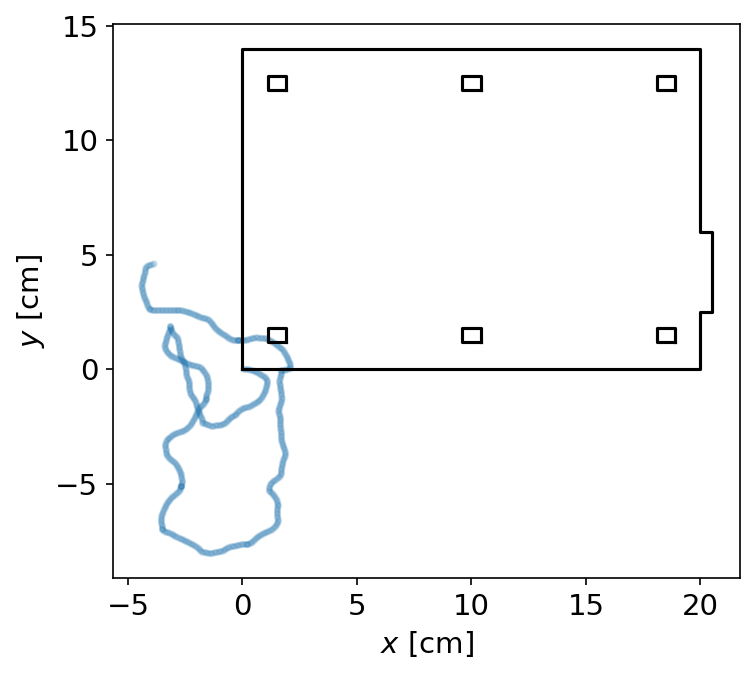

In [173]:
dt = 1/60
totalTime = 30
Dr = 3e-1
tau = 1.4
sigma = 1
v = 15

walkArr = walkFunc(totalTime, dt, tau, sigma, v, Dr)

plt.scatter(*(walkArr.T / 10), alpha=0.05, s=6)

plt.plot(*np.concatenate((boundaryPoints, boundaryPoints[:1])).T/10, c='black', linestyle='-')
for i in range(len(postBoundaries)):
    plt.plot(*np.concatenate((postBoundaries[i], postBoundaries[i][:1])).T/10, c='black', linestyle='-')

plt.xlabel('$x$ [cm]')
plt.ylabel('$y$ [cm]')
plt.gca().set_aspect(1)
plt.show()

## Generate a single dataset

In [252]:
dt = 1/60
totalTime = 1200
Dr = 1e-1
tau = 1.27
sigma = 1.01
v = 16.27

# Number of cores to use
numProcesses = 4

numSamples = 50

dataArr = []
mutex = multiprocessing.Lock()

with multiprocessing.Pool(processes=numProcesses) as pool:

    def target(i):
        np.random.seed(i)
        while True:
            data = walkFunc(totalTime, dt, tau, sigma, v, Dr)
        
            if np.isnan(data).any():
                continue
                
            return data
        
    for data in tqdm(pool.imap_unordered(target, range(numSamples))):
        mutex.acquire()
        dataArr.append(data)
        mutex.release()


50it [02:17,  2.76s/it]


### Save the data

This will save the data in the same format as the experimental data, such that the same notebooks/scripts can be used to analyze it.

In [253]:
# Now we save the compiled data into a single file
#outputFile = '/home/jack/Workspaces/data/ant_simulation/unbounded_test_dataset_true.h5'
outputFile = '/home/jack/Workspaces/data/ant_simulation/bounded_test_dataset_true.h5'

with h5py.File(outputFile, 'w') as f:
    # Create a group for each segment we have.    
    for i in range(len(dataArr)):
        # Metadata is just manually entered
        dictionary = {}
        
        dictionary["dataset"] = f'Simulated:{i:3}'
        dictionary["name"] = dictionary["dataset"]
        
        # Within the group, we have a dataset for the position of the ant,
        # and a dataset for the time arr of the tracking. The time arr is
        # of course an equally spaced, continuous array, so slightly
        # wasteful to store, but again, the goal is to be able to swap
        # this file in for the real ones.
        timeArr = np.arange(len(dataArr[i]))
        dataset = f.create_dataset(f'{dictionary["name"]}/frames', data=timeArr.astype(np.float64))
        dataset = f.create_dataset(f'{dictionary["name"]}/points', data=dataArr[i].astype(np.float64))

        # Attach metadata
        # Note that we won't have every entry that the real data has (eg.
        # SLEAP information) but we have the most important ones.
        
        dictionary["fps"] = 1./dt        
        dictionary["outlier"] = False
        dictionary["outlier_reason"] = ''

        # These should all be cleaned, since there are certainly no correlations.
        dictionary["cleaned"] = True
        dictionary["objects"] = '[]'
        
        # Add the data about scaling
        dictionary["convertedToMM"] = True
        
        dictionary["totalTimeSeconds"] = totalTime
        dictionary["totalTimeMinutes"] = totalTime / 60

        # And add simulation parameters
        dictionary["Dr"] = Dr
        dictionary["Dx"] = Dx
        dictionary["angleSigma"] = sigma
        dictionary["tau"] = tau
        dictionary["v"] = v
        dictionary["waitingTimeDistExponent"] = waitingTimeExponent

        dataset.attrs.update(dictionary)

## Generate many datasets

In [221]:
dt = 1/60
totalTime = 1200

tauArr = [0.5, 1, 1.5, 2]
sigmaArr = [0.5, 1, 1.5, 2]
vArr = [20]
DRArr = np.logspace(-2, -1, 4)#[1e-2, 5e-2, 1e-1]

# Number of cores to use
numProcesses = 4

numSamples = 80

outputFolder = '/home/jack/Workspaces/data/ant_simulation/bounded/'

totalSimulations = len(tauArr)*len(sigmaArr)*len(DRArr)*len(vArr)
dataArr = []
mutex = multiprocessing.Lock()

def target(params):
    tau, sigma, v, Dr = params

    dataArr = []
    for i in range(numSamples):
        np.random.seed(int(time.perf_counter()))
        while True:
            data = walkFunc(totalTime, dt, tau, sigma, v, Dr)
        
            if np.isnan(data).any():
                continue
                
            dataArr.append(data)
            break

    # Now we save the data
    outputName = f'simulation_tau{tau}_sigma{sigma}_v{v}_Dr{Dr}.h5'
    outputFile = os.path.join(outputFolder, outputName)
    
    with h5py.File(outputFile, 'w') as f:
        for i in range(len(dataArr)):
            dictionary = {}
            
            dictionary["dataset"] = f'Simulated:{i:3}'
            dictionary["name"] = dictionary["dataset"]
            
            timeArr = np.arange(len(dataArr[i]))
            dataset = f.create_dataset(f'{dictionary["name"]}/frames', data=timeArr.astype(np.float32))
            dataset = f.create_dataset(f'{dictionary["name"]}/points', data=dataArr[i].astype(np.float32))
                
            dictionary["fps"] = 1./dt        
            dictionary["outlier"] = False
            dictionary["outlier_reason"] = ''
    
            dictionary["cleaned"] = True
            dictionary["objects"] = '[]'
            
            dictionary["convertedToMM"] = True
            
            dictionary["totalTimeSeconds"] = totalTime
            dictionary["totalTimeMinutes"] = totalTime / 60
    
            dictionary["Dr"] = Dr
            dictionary["Dx"] = Dx
            dictionary["angleSigma"] = sigma
            dictionary["tau"] = tau
            dictionary["v"] = v
            dictionary["waitingTimeDistExponent"] = waitingTimeExponent
            dataset.attrs.update(dictionary)

with multiprocessing.Pool(processes=numProcesses) as pool:

    def generator():
        for tau in tauArr:
            for sigma in sigmaArr:
                for v in vArr:
                    for Dr in DRArr:
                        yield tau, sigma, v, Dr
        
    for data in tqdm(pool.imap_unordered(target, generator()), total=totalSimulations):
        mutex.acquire()
        dataArr.append(data)
        mutex.release()


100%|█████████████████████████████████████████| 64/64 [1:14:54<00:00, 70.22s/it]


## Occupation map

In [73]:
# Compute the edges of the arena from the trajectories
# (accounting for padding if we have any).
minDataPoints = np.min([np.min(d, axis=0) for d in dataArr if len(d) > 1], axis=0)
maxDataPoints = np.max([np.max(d, axis=0) for d in dataArr if len(d) > 1], axis=0)

numBins = 50
scalingFactor = (maxDataPoints - minDataPoints)
scalingFactor /= np.max(scalingFactor)

xBins = np.linspace(minDataPoints[0], maxDataPoints[0], int(scalingFactor[0]*numBins+1))
yBins = np.linspace(minDataPoints[1], maxDataPoints[1], int(scalingFactor[1]*numBins+1))

# The midpoints of the bins that we will use to plot
xBinArr = (xBins[1:] + xBins[:-1]) / 2
yBinArr = (yBins[1:] + yBins[:-1]) / 2

occupationMapArr = np.zeros((len(dataArr), int(scalingFactor[0]*numBins), int(scalingFactor[1]*numBins)))
noWallOccupationMapArr = np.zeros((len(dataArr), int(scalingFactor[0]*numBins), int(scalingFactor[1]*numBins)))

for i in tqdm(range(len(dataArr))):
    hist, x, y = np.histogram2d(*dataArr[i].T, bins=[xBins, yBins])
    occupationMapArr[i] = hist * dt

# for i in tqdm(range(len(noWallDataArr))):
#     hist, x, y = np.histogram2d(*noWallDataArr[i].T, bins=[xBins, yBins])
#     noWallOccupationMapArr[noWallIndexDict[noWallMetadataArr[i]["name"]]] += hist / noWallMetadataArr[i]["fps"]

100%|████████████████████████████████████████| 100/100 [00:00<00:00, 663.15it/s]


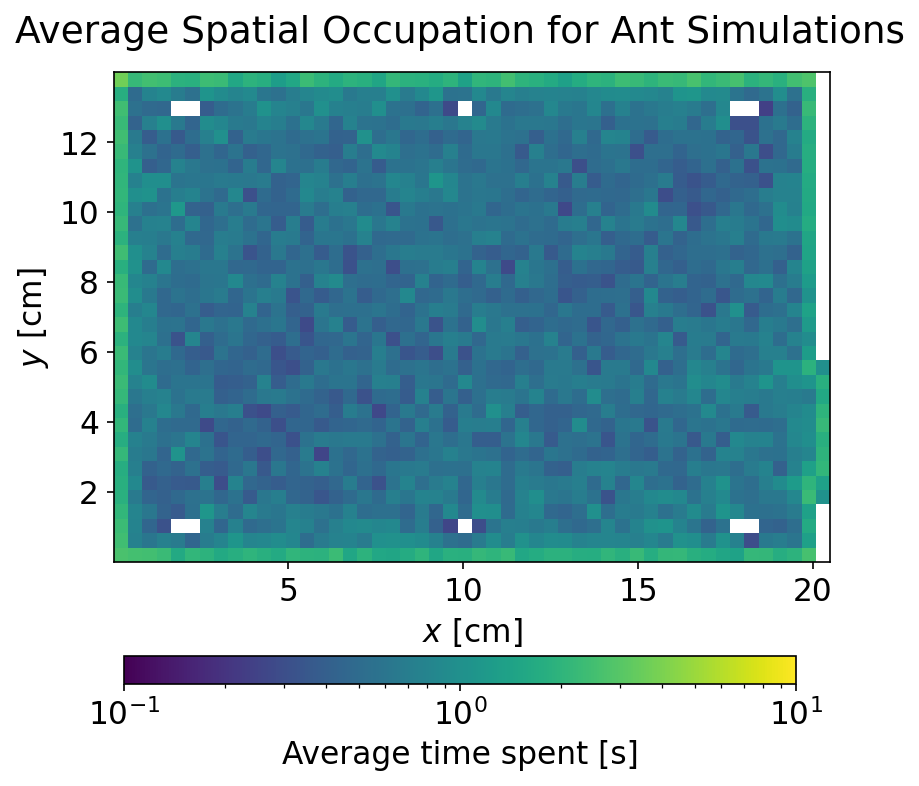

In [76]:
fig, ax = plt.subplots()
cmap = plt.get_cmap('viridis')

normData = np.sum(occupationMapArr, axis=0) / len(dataArr)
#cmapNorm = mpl.colors.LogNorm(vmin=np.nanmin(normData)+2e-1, vmax=np.nanmax(normData))
cmapNorm = mpl.colors.LogNorm(vmin=1e-1, vmax=1e1)

pcolor = ax.pcolormesh(xBinArr / 10, yBinArr / 10, normData.T , cmap=cmap, norm=cmapNorm, rasterized=True)

ax.set_ylabel('$y$ [cm]')
ax.set_xlabel('$x$ [cm]')

ax.set_aspect(1)

# fig.subplots_adjust(right=0.85)
# cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])

fig.subplots_adjust(bottom=0.2)
cbar_ax = fig.add_axes([0.15, 0.03, 0.7, 0.04])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=cmapNorm, cmap=cmap),
                    cax=cbar_ax,
                    label='Average time spent [s]', orientation='horizontal')

fig.suptitle('Average Spatial Occupation for Ant Simulations', y=0.96)
#pltsaveall('03_AllOccupationMap')
plt.show()

## Parameter space map

In [68]:
# Compute the orientation of the walker
def computeOrientation(trajectoryArr):
    """
    """
    # We will need the step sizes (in the measured frame)
    # to weight the contributions to the overall run direction
    originalStepDirectionArr = trajectoryArr[1:] - trajectoryArr[:-1]
   
    # Compute the orientation (angle) of the walker at each step.
    absoluteAngleArr = np.arctan2(*(originalStepDirectionArr.T / np.sqrt(np.sum(originalStepDirectionArr**2, axis=-1))))

    # This will have length one less than trajectory arr, so we duplicate the value at the beginning
    # so it can be indexed the same.
    absoluteAngleArr = np.concatenate((absoluteAngleArr[:1], absoluteAngleArr))

    if len(absoluteAngleArr) > 5:
        # Smooth gently
        absoluteAngleArr = savgol_filter(absoluteAngleArr, 5, 1)
    
    return absoluteAngleArr

In [69]:
numSpatialBins = 50
numAngleBins = 20

# Compute the edges of the arena from the trajectories
# (accounting for padding if we have any).
minDataPoints = np.min([np.min(d, axis=0) for d in dataArr if len(d) > 1], axis=0)
maxDataPoints = np.max([np.max(d, axis=0) for d in dataArr if len(d) > 1], axis=0)

scalingFactor = (maxDataPoints - minDataPoints)
scalingFactor /= np.max(scalingFactor)

xBins = np.linspace(minDataPoints[0], maxDataPoints[0], int(scalingFactor[0]*numSpatialBins+1))
yBins = np.linspace(minDataPoints[1], maxDataPoints[1], int(scalingFactor[1]*numSpatialBins+1))
#angleBins = np.linspace(-np.pi, np.pi, numAngleBins+1)
angleBins = np.linspace(-np.pi * (1 + 1/numAngleBins), np.pi * (1 - 1/numAngleBins), numAngleBins+1)

# The midpoints of the bins that we will use to plot
xBinArr = (xBins[1:] + xBins[:-1]) / 2
yBinArr = (yBins[1:] + yBins[:-1]) / 2
angleBinArr = (angleBins[1:] + angleBins[:-1]) / 2

occupationMapArr = np.zeros((len(dataArr),
                             int(scalingFactor[0]*numSpatialBins),
                             int(scalingFactor[1]*numSpatialBins),
                             numAngleBins))

for i in tqdm(range(len(dataArr))):
    if len(dataArr[i]) <= 1:
        continue
        
    angles = computeOrientation(dataArr[i])
    parameterSpaceArr = np.zeros((len(dataArr[i]), 3))
    parameterSpaceArr[:,:2] = dataArr[i]
    parameterSpaceArr[:,-1] = angles
    
    hist, bins = np.histogramdd(parameterSpaceArr, bins=[xBins, yBins, angleBins])
    occupationMapArr[i] = hist * dt

  0%|                                                   | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_87046/2625513920.py:10: RuntimeWarning: invalid value encountered in divide
  absoluteAngleArr = np.arctan2(*(originalStepDirectionArr.T / np.sqrt(np.sum(originalStepDirectionArr**2, axis=-1))))
100%|████████████████████████████████████████| 100/100 [00:00<00:00, 176.08it/s]


/tmp/ipykernel_87046/2278878644.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


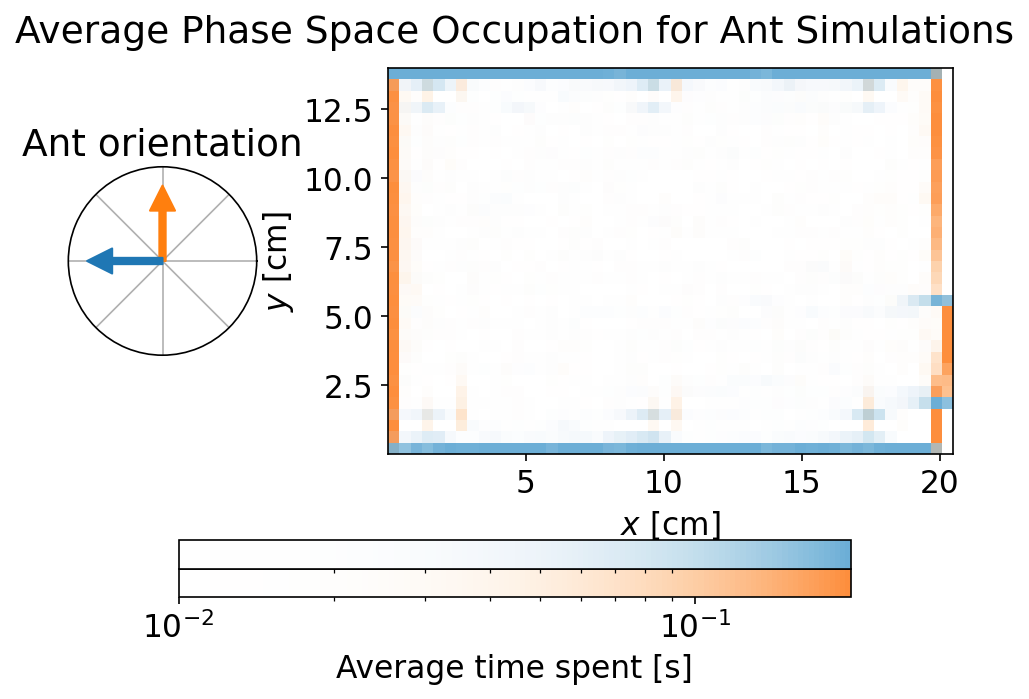

In [70]:
testAngleIndices = [10, 5]#, 15]
colors = ['tab:blue', 'tab:orange'][::-1]
colorMaps = ['Blues', 'Oranges'][::-1]

fig = plt.figure()
gs = mpl.gridspec.GridSpec(1, 2, width_ratios=[1,3])

radialAx = fig.add_subplot(gs[0], projection='polar')
ax = fig.add_subplot(gs[1])
fig.subplots_adjust(bottom=0.30)

for i in range(len(testAngleIndices)):
    angleIndex = testAngleIndices[i]
    
    #radialAx.arrow(0, 0, np.cos(angleBinArr[angleIndex]), np.sin(angleBinArr[angleIndex]), width=0.1)
    radialAx.set_title('Ant orientation')
    radialAx.annotate("", xytext=(0.5, 0.5), xy=(0.5 + 0.4 * np.sin(angleBinArr[angleIndex]), 0.5 + 0.4 * np.cos(angleBinArr[angleIndex])),
                      arrowprops={"width": 3, "color": colors[i]}, xycoords='axes fraction')
    
    radialAx.set_rticks([])
    radialAx.set_xticks(radialAx.get_xticks(), labels=['']*8)
    
    # Choose colormap
    cmap = plt.get_cmap(colorMaps[i])
    
    # Get the colormap colors
    my_cmap = cmap(np.arange(cmap.N))[:cmap.N//2]
    
    # Set alpha
    my_cmap[:,-1] = np.linspace(0, 1, cmap.N//2)**2
    #my_cmap[:,-1] = 0.1
    
    # Create new colormap
    my_cmap = mpl.colors.ListedColormap(my_cmap)

    normData = np.sum(occupationMapArr[:,:,:,angleIndex], axis=0) / len(dataArr)
    # Chosen manually to be constant
    cmapNorm = mpl.colors.LogNorm(vmin=10**(-2),
                                  vmax=10**(-0.7))
    #cmapNorm = mpl.colors.LogNorm(vmin=np.nanmin(normData)+dt,
    #                              vmax=np.nanmax(normData))
    
    #cmapNorm = mpl.colors.PowerNorm(gamma=1, vmin=400, vmax=np.nanmax(occupationMapArr))
    
    pcolor = ax.pcolormesh(xBinArr / 10, yBinArr / 10, normData.T, cmap=my_cmap, norm=cmapNorm, rasterized=True)
    
    ax.set_ylabel('$y$ [cm]')
    ax.set_xlabel('$x$ [cm]')
    
    ax.set_aspect(1)
    
    cbar_ax = fig.add_axes([0.15, 0.02 + 0.04*i, 0.70, 0.04])
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=cmapNorm, cmap=my_cmap),
                        cax=cbar_ax,
                        orientation='horizontal')

    if i == 0:
        cbar.set_label('Average time spent [s]')
    else:
        cbar.set_ticks([])
        
fig.suptitle('Average Phase Space Occupation for Ant Simulations', y=0.83)
fig.tight_layout()
#pltsaveall(f'03_AllParameterSpaceMap')
plt.show()

## Comparison with real data

In [97]:
dataFile = '/home/jack/Workspaces/data/ant_tracking/ant_dataset_1_2026-02-01.h5'

minimumLength = 20 # seconds
smoothingWindow = 10 # frames
maximumTimeSkip = 10 # frames

excludeOutliers = True
excludeShortSegments = True
excludeObjects = True

padding = None # mm
inversePadding = None # mm

dataArr, timeArr, metadataArr = loadAntData(dataFile, minimumLength=minimumLength,
                                            smoothingWindow=smoothingWindow, maximumTimeSkip=maximumTimeSkip,
                                            excludeOutliers=excludeOutliers, excludeShortSegments=excludeShortSegments,
                                            excludeObjects=excludeObjects,
                                            borderPadding=padding, inverseBorderPadding=inversePadding,
                                            debug=True)

Loading SLEAP data: 100%|██████████████████| 1434/1434 [00:02<00:00, 587.52it/s]

Loaded 334 segments!


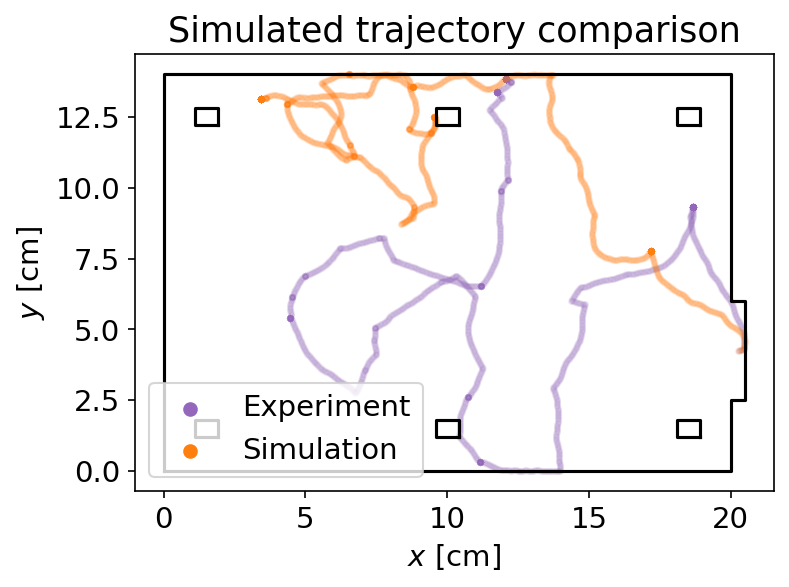

In [301]:
realIndex = 1

dt = 1/60
totalTime = 60
Dr = 3e-1
tau = 1.4
sigma = 1
v = 15

# We have translate the data since it might have an offset 
# compared to the simulated data
expArr = dataArr[realIndex]
expArr = expArr - np.min(expArr, axis=0)
expArr = expArr[:int(totalTime / dt)]

plt.scatter(*(expArr.T / 10), alpha=0.05, s=6, c='tab:purple', rasterized=True)
plt.scatter(None, None, c='tab:purple', label='Experiment')

np.random.seed(0)
walkArr = walkFunc(totalTime, dt, tau, sigma, v, Dr)

plt.scatter(*(walkArr.T / 10), alpha=0.05, s=6, c='tab:orange', rasterized=True)
plt.scatter(None, None, c='tab:orange', label='Simulation')

plt.plot(*np.concatenate((boundaryPoints, boundaryPoints[:1])).T/10, c='black', linestyle='-')
for i in range(len(postBoundaries)):
    plt.plot(*np.concatenate((postBoundaries[i], postBoundaries[i][:1])).T/10, c='black', linestyle='-')

plt.xlabel('$x$ [cm]')
plt.ylabel('$y$ [cm]')
plt.gca().set_aspect(1)
plt.legend()
plt.title('Simulated trajectory comparison')
plt.gcf().set_size_inches((5.5,4))
plt.savefig('simulation_comparison.pdf', bbox_inches='tight')
plt.show()

## MSD

In [254]:
dataFile = '/home/jack/Workspaces/data/ant_simulation/bounded_test_dataset_true.h5'

# We will want to look at longer trajectories here since we want to examine
# timescales longer than 15 seconds.
minimumLength = 5 # seconds
smoothingWindow = 10 # frames
maximumTimeSkip = 10 # frames

excludeOutliers = True
excludeShortSegments = True
excludeObjects = True

padding = None # mm
inversePadding = None # mm

boundedDataArr, boundedTimeArr, boundedMetadataArr = loadAntData(dataFile, minimumLength=minimumLength,
                                                                smoothingWindow=smoothingWindow, maximumTimeSkip=maximumTimeSkip,
                                                                excludeOutliers=excludeOutliers, excludeShortSegments=excludeShortSegments,
                                                                excludeObjects=excludeObjects,
                                                                borderPadding=padding, inverseBorderPadding=inversePadding,
                                                                debug=True)

Loading SLEAP data: 100%|██████████████████████| 50/50 [00:00<00:00, 188.93it/s]

Loaded 50 segments!


In [268]:
maxTime = 500 # [s]
bins = 30

dt = 1/boundedMetadataArr[0]["fps"]

# We store things based on the original trial they come
# from, so we can get the average (or median) value for each trial,
# plus the overall average. See comments above this cell.
trialMembership = np.array([m["dataset"] for m in boundedMetadataArr])
uniqueTrials = np.unique(trialMembership)
indexDict = dict(zip(uniqueTrials, np.arange(len(uniqueTrials))))
# trialIndicesArr[i] gives the indices of all of the segments that belong to trial i
trialIndicesArr = [np.where(trialMembership == trial)[0] for trial in uniqueTrials]

boundedMSDArr = np.zeros((len(uniqueTrials), bins))

for j in tqdm(range(len(uniqueTrials))): 
    segmentList = [boundedDataArr[k] for k in trialIndicesArr[j]]
    timeList = [boundedTimeArr[k] for k in trialIndicesArr[j]]
    
    lagArr, boundedMSDArr[j] = computeMSD(segmentList, t=timeList,
                                   minLag=2*dt, maxLag=maxTime, nbins=bins, logbins=True)

100%|███████████████████████████████████████████| 50/50 [00:09<00:00,  5.12it/s]


In [269]:
dataFile = '/home/jack/Workspaces/data/ant_simulation/unbounded_test_dataset_true.h5'

# We will want to look at longer trajectories here since we want to examine
# timescales longer than 15 seconds.
minimumLength = 5 # seconds
smoothingWindow = 10 # frames
maximumTimeSkip = 10 # frames

excludeOutliers = True
excludeShortSegments = True
excludeObjects = True

padding = None # mm
inversePadding = None # mm

unboundedDataArr, unboundedTimeArr, unboundedMetadataArr = loadAntData(dataFile, minimumLength=minimumLength,
                                                                smoothingWindow=smoothingWindow, maximumTimeSkip=maximumTimeSkip,
                                                                excludeOutliers=excludeOutliers, excludeShortSegments=excludeShortSegments,
                                                                excludeObjects=excludeObjects,
                                                                borderPadding=padding, inverseBorderPadding=inversePadding,
                                                                debug=True)

Loading SLEAP data: 100%|██████████████████████| 50/50 [00:00<00:00, 205.88it/s]

Loaded 50 segments!


In [273]:
maxTime = 500 # [s]
bins = 30

dt = 1/unboundedMetadataArr[0]["fps"]

# We store things based on the original trial they come
# from, so we can get the average (or median) value for each trial,
# plus the overall average. See comments above this cell.
trialMembership = np.array([m["dataset"] for m in unboundedMetadataArr])
uniqueTrials = np.unique(trialMembership)
indexDict = dict(zip(uniqueTrials, np.arange(len(uniqueTrials))))
# trialIndicesArr[i] gives the indices of all of the segments that belong to trial i
trialIndicesArr = [np.where(trialMembership == trial)[0] for trial in uniqueTrials]

unboundedMSDArr = np.zeros((len(uniqueTrials), bins))

for j in tqdm(range(len(uniqueTrials))): 
    segmentList = [unboundedDataArr[k] for k in trialIndicesArr[j]]
    timeList = [unboundedTimeArr[k] for k in trialIndicesArr[j]]
    
    lagArr, unboundedMSDArr[j] = computeMSD(segmentList, t=timeList,
                                   minLag=2*dt, maxLag=maxTime, nbins=bins, logbins=True)

100%|███████████████████████████████████████████| 50/50 [00:10<00:00,  4.87it/s]


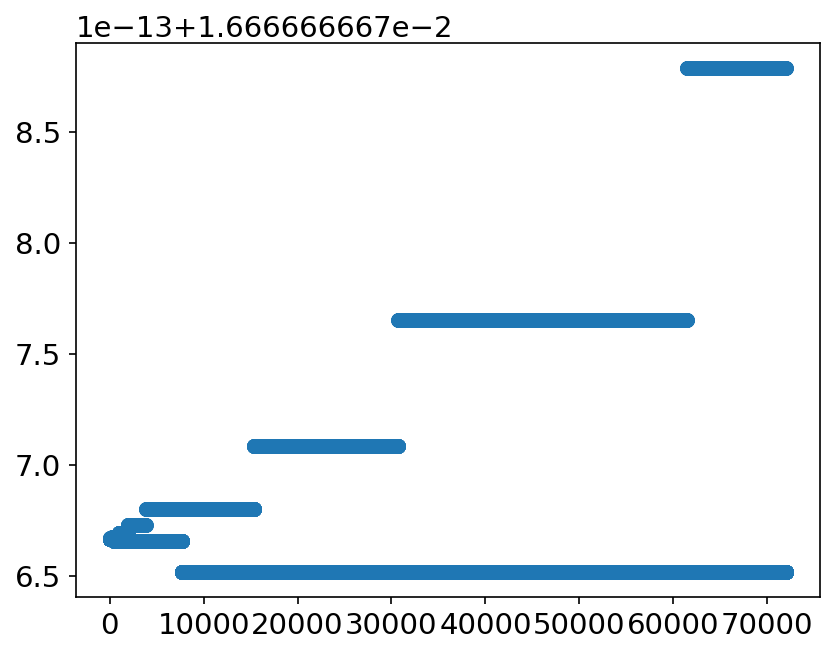

In [245]:
plt.plot(timeList[0][1:] - timeList[0][:-1], 'o')
plt.show()

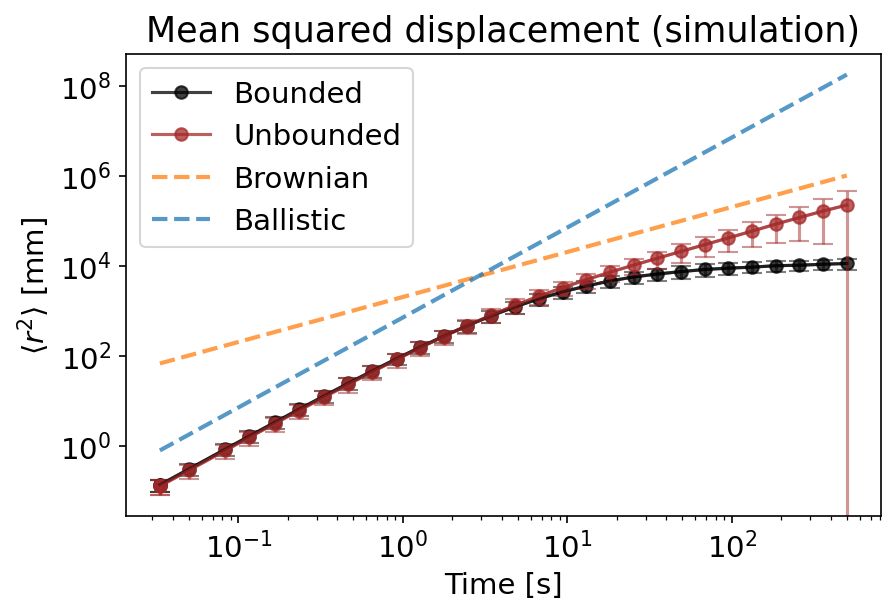

In [305]:
order = np.arange(len(uniqueTrials))
np.random.shuffle(order)

colors = ['black', 'brown']
#for i in order:
#    plt.plot(lagArr, boundedMSDArr[i], '-', alpha=0.05)

mean = np.nanmean(boundedMSDArr, axis=0)
plt.plot(lagArr, mean, '-o', c=colors[0], label='Bounded', alpha=0.75)

std = np.nanstd(boundedMSDArr, axis=0)

plt.errorbar(lagArr, mean, yerr=std, color=colors[0], alpha=0.5, capsize=5)

mean = np.nanmean(unboundedMSDArr, axis=0)
plt.plot(lagArr, mean, '-o', c=colors[1], label='Unbounded', alpha=0.75)

std = np.nanstd(unboundedMSDArr, axis=0)

plt.errorbar(lagArr, mean, yerr=std, color=colors[1], alpha=0.5, capsize=5)

plt.plot(lagArr, 2000*(lagArr)**1, '--', c='tab:orange', label='Brownian', alpha=0.75, linewidth=2)
plt.plot(lagArr, 700*(lagArr)**2, '--', c='tab:blue', label='Ballistic', alpha=0.75, linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time [s]')
plt.ylabel('$\\langle r^2 \\rangle$ [mm]')
#plt.title(f'Mean Squared Displacement for Ant Motion\nUncropped')
plt.title(f'Mean squared displacement (simulation)')#\nCropped at walls (1.5cm)')
#plt.title(f'Mean Squared Displacement for Ant Motion\nOnly at walls (2 cm)')
plt.legend()
plt.gcf().set_size_inches((6.5,4))
plt.savefig('simulation_msd.pdf', bbox_inches='tight')
plt.show()

In [198]:
timeList[0]

array([0.0000000e+00, 1.6666668e-02, 3.3333335e-02, ..., 1.1999500e+03,
       1.1999667e+03, 1.1999833e+03], dtype=float32)